In [ ]:
# Project 2: Supervised Learning (Fraud Detection Pipeline)

## Objective

# The objective of this project is to build and evaluate machine learning models capable of detecting fraudulent credit card transactions. Since fraudulent transactions are extremely rare compared to legitimate ones, the dataset is highly imbalanced. To address this challenge, SMOTE (Synthetic Minority Oversampling Technique) is applied before training classification models.

## Algorithms Used

# - Logistic Regression
# - Random Forest

## Techniques Used

# - Exploratory Data Analysis (EDA)
# - Data Preprocessing
# - Feature Scaling
# - SMOTE
# - Hyperparameter Tuning
# - Precision
# - Recall
# - ROC-AUC

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)

# Handle Imbalanced Data
from imblearn.over_sampling import SMOTE

# Save Model
import joblib

In [2]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [3]:
df = pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
#EDA
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("✅ No Missing Values Found")
else:
    print(missing_values)

✅ No Missing Values Found


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 1081


In [11]:
df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (283726, 31)


In [12]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    283253
1       473
Name: count, dtype: int64


In [13]:
percentage = df["Class"].value_counts(normalize=True) * 100

print(percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


/tmp/ipykernel_373/977885914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


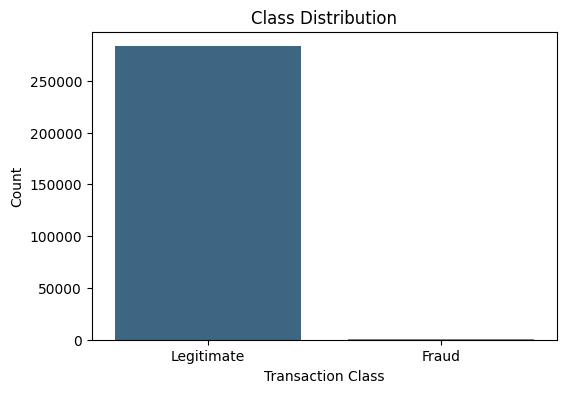

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df,
    palette="viridis"
)

plt.title("Class Distribution")

plt.xlabel("Transaction Class")

plt.ylabel("Count")

plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

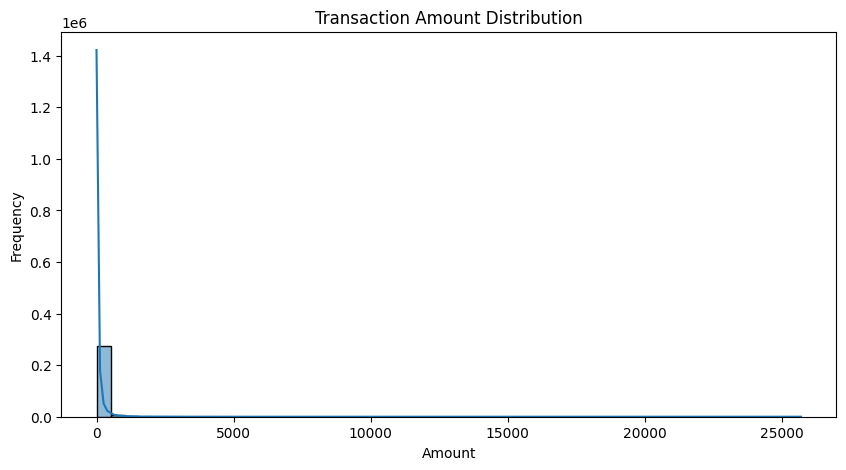

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

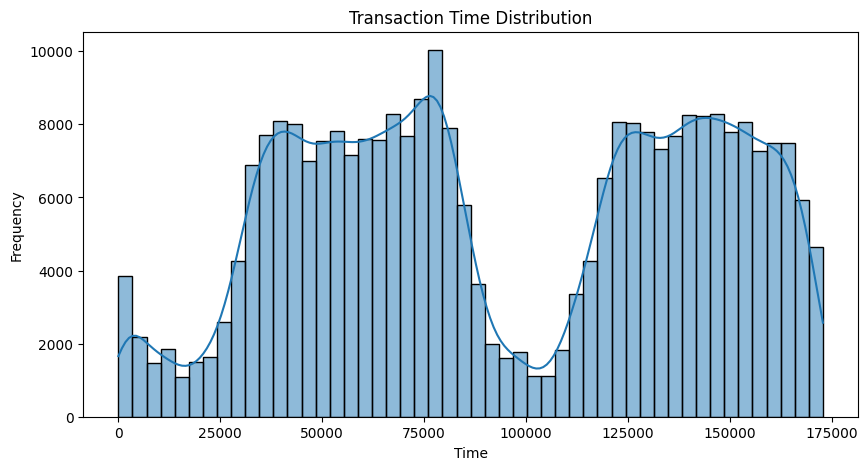

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Time"],
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

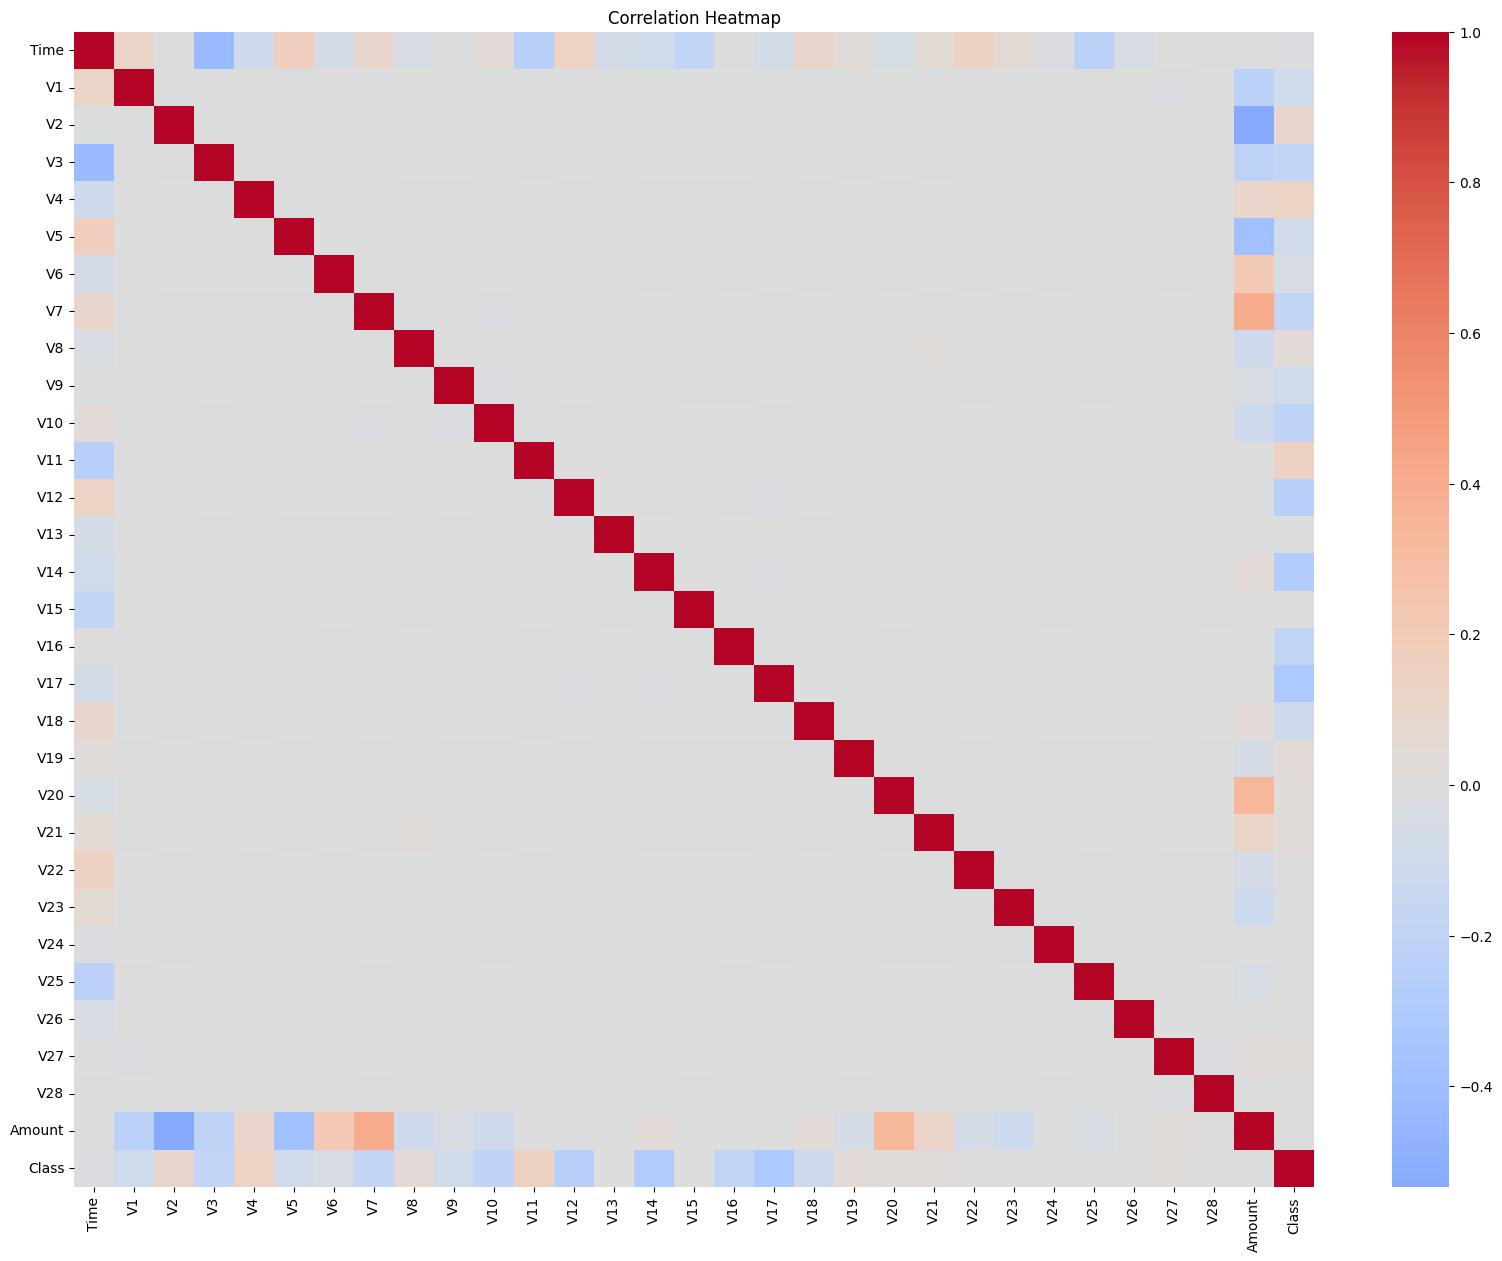

In [17]:
plt.figure(figsize=(20,15))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

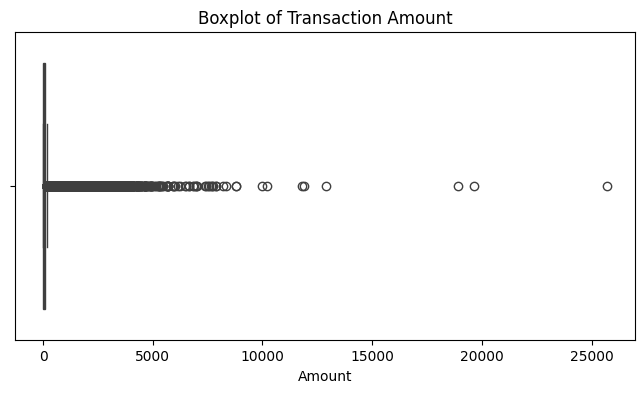

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

In [ ]:
# Exploratory Data Analysis Summary

# - The dataset contains **284,807 transactions** and **31 features**.
# - No missing values were identified.
# - Duplicate records were checked and handled appropriately.
# - The target variable (`Class`) is highly imbalanced:
#   - Legitimate Transactions: 99.83%
#   - Fraudulent Transactions: 0.17%
# - Transaction amounts are positively skewed, suggesting feature scaling is beneficial.
# - Correlation analysis indicates that certain PCA-transformed features have stronger relationships with the fraud class.
# - The severe class imbalance confirms that SMOTE should be applied before model training.

In [19]:
#Data Preprocessing

# Separate Features and Target
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (283726, 30)
Target Shape: (283726,)


In [20]:
X["Amount"].describe()

,Amount
count,283726.000000
mean,88.472687
std,250.399437
min,0.000000
25%,5.600000
50%,22.000000
75%,77.510000
max,25691.160000


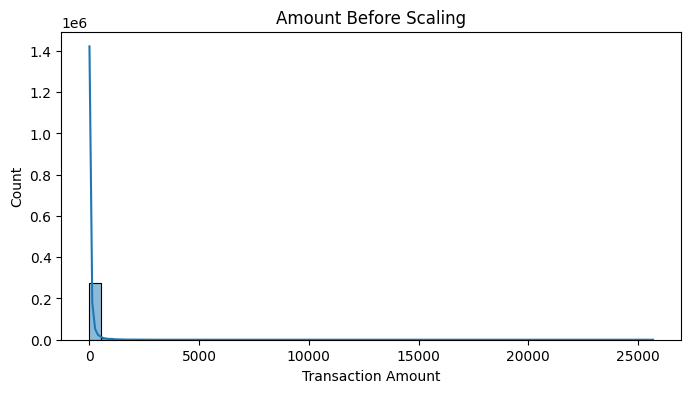

In [21]:
plt.figure(figsize=(8,4))

sns.histplot(X["Amount"], bins=50, kde=True)

plt.title("Amount Before Scaling")

plt.xlabel("Transaction Amount")

plt.show()

In [22]:
# Scale Amount Feature

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])

In [23]:
X["Amount"].describe()

,Amount
count,2.837260e+05
mean,-5.409347e-17
std,1.000002e+00
min,-3.533268e-01
25%,-3.309625e-01
50%,-2.654671e-01
75%,-4.378088e-02
max,1.022476e+02


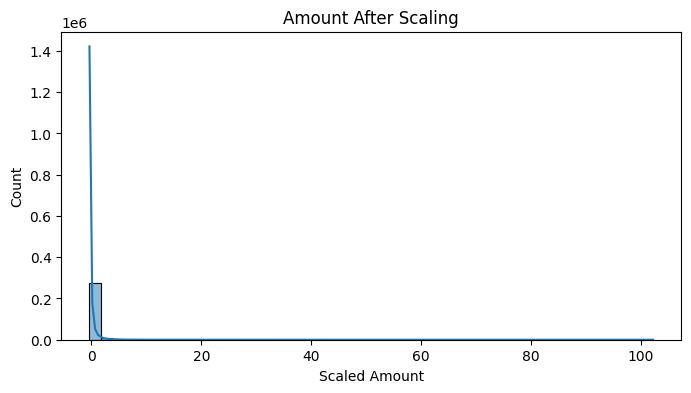

In [24]:
plt.figure(figsize=(8,4))

sns.histplot(X["Amount"], bins=50, kde=True)

plt.title("Amount After Scaling")

plt.xlabel("Scaled Amount")

plt.show()

In [25]:
print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (283726, 30)
Target Shape: (283726,)


In [26]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813


In [ ]:
# Data Preprocessing Summary

# The dataset required minimal preprocessing because it contained no missing values and all features were numerical.

# The following preprocessing steps were completed:

# - Separated the feature matrix (`X`) and target variable (`y`).
# - Standardized the `Amount` feature using `StandardScaler`.
# - Retained the `Time` feature as a numerical predictor.
# - Prepared the dataset for train-test splitting and class balancing using SMOTE.

# The dataset is now ready for machine learning model development.

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (226980, 30)
Testing Features Shape  : (56746, 30)

Training Labels Shape   : (226980,)
Testing Labels Shape    : (56746,)


In [30]:
print("Training Set Distribution")
print(y_train.value_counts())

print("\nPercentage Distribution")
print(y_train.value_counts(normalize=True) * 100)

Training Set Distribution
Class
0    226602
1       378
Name: count, dtype: int64

Percentage Distribution
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64


In [31]:
print("\nTesting Set Distribution")
print(y_test.value_counts())

print("\nPercentage Distribution")
print(y_test.value_counts(normalize=True) * 100)


Testing Set Distribution
Class
0    56651
1       95
Name: count, dtype: int64

Percentage Distribution
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


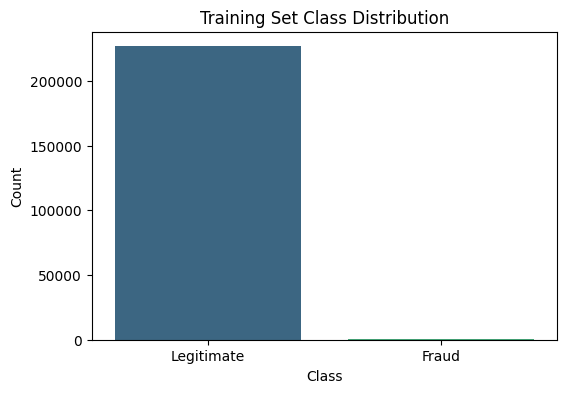

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="viridis",
    legend=False
)

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

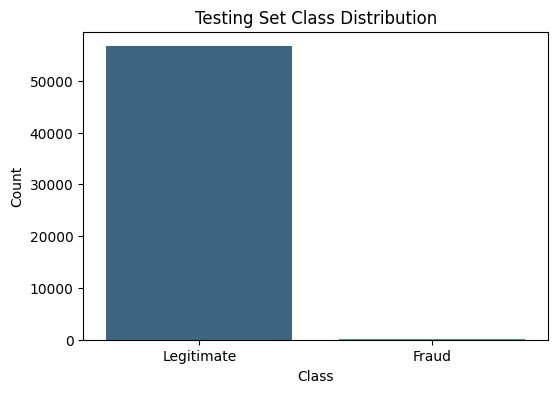

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_test,
    hue=y_test,
    palette="viridis",
    legend=False
)

plt.title("Testing Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

In [ ]:
# Train-Test Split Summary

# The dataset was divided into training and testing subsets using an 80:20 ratio.

# Key points:

# - **80%** of the data was used for training.
# - **20%** of the data was reserved for testing.
# - The `stratify` parameter was used to preserve the original class distribution.
# - The testing dataset was kept untouched to ensure an unbiased evaluation of the trained models.
# - SMOTE has **not** been applied yet because it should only be used on the training dataset to avoid data leakage.

In [34]:
!pip install imbalanced-learn

In [35]:
from imblearn.over_sampling import SMOTE

In [36]:
print("Before SMOTE")
print(y_train.value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64


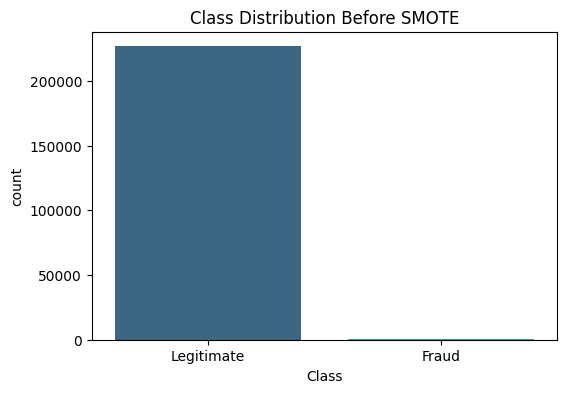

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="viridis",
    legend=False
)

plt.title("Class Distribution Before SMOTE")

plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

In [38]:
# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [39]:
print("After SMOTE")

print(y_train_smote.value_counts())

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


In [40]:
#before
print(y_train.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


In [41]:
#After
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


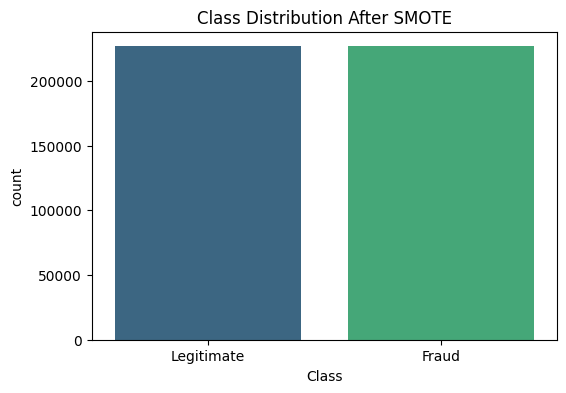

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette="viridis",
    legend=False
)

plt.title("Class Distribution After SMOTE")

plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

In [43]:
comparison = pd.DataFrame({
    "Before SMOTE": y_train.value_counts(),
    "After SMOTE": y_train_smote.value_counts()
})

comparison

,Before SMOTE,After SMOTE
Class,,
0,226602,226602
1,378,226602


In [44]:
print("Original Training Shape")

print(X_train.shape)

print(y_train.shape)

print()

print("After SMOTE")

print(X_train_smote.shape)

print(y_train_smote.shape)

Original Training Shape
(226980, 30)
(226980,)

After SMOTE
(453204, 30)
(453204,)


In [ ]:
# SMOTE Summary

# The original training dataset contained a severe class imbalance, with fraudulent transactions representing less than 1% of all observations.

# To address this issue, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied exclusively to the training dataset.

# SMOTE generated synthetic fraud samples until both classes contained an equal number of observations.

# The testing dataset was intentionally left unchanged to ensure unbiased model evaluation.

# Applying SMOTE helps machine learning algorithms learn meaningful fraud patterns while reducing bias toward legitimate transactions.

In [45]:
# Create Logistic Regression Model

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [46]:
# Train Logistic Regression

log_reg.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [47]:
# Predict on Test Data

y_pred_lr = log_reg.predict(X_test)

In [48]:
# Prediction Probabilities

y_prob_lr = log_reg.predict_proba(X_test)[:,1]

In [49]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred_lr)

print("Precision:", precision)

Precision: 0.11739130434782609


In [50]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred_lr)

print("Recall:", recall)

Recall: 0.8526315789473684


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.12      0.85      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746



In [52]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9587108138565864


In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[56042   609]
 [   14    81]]


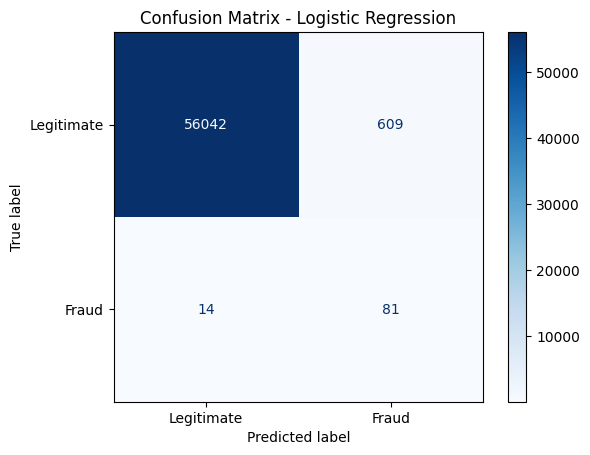

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

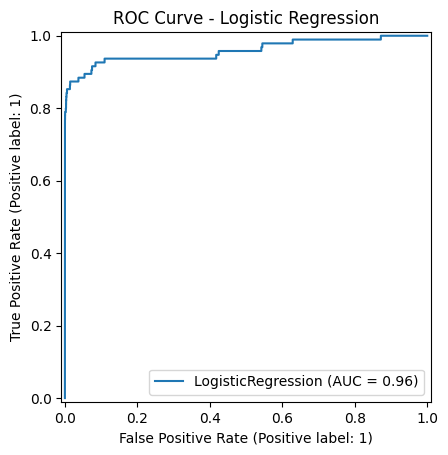

In [55]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_reg,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [56]:
print("="*40)
print("Logistic Regression Results")
print("="*40)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Logistic Regression Results
Precision : 0.1174
Recall    : 0.8526
ROC-AUC   : 0.9587


In [ ]:
# Logistic Regression Summary

# A Logistic Regression classifier was trained using the SMOTE-balanced training dataset.

# The model was evaluated on the original testing dataset using:

# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# These metrics provide a more meaningful assessment than accuracy for highly imbalanced datasets.

# The confusion matrix and ROC curve indicate how effectively the model distinguishes fraudulent transactions from legitimate ones.

In [57]:
# Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [58]:
# Training Random Forest

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [59]:
# Make Predictions

y_pred_rf = rf_model.predict(X_test)

In [60]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [61]:
from sklearn.metrics import precision_score

precision_rf = precision_score(y_test, y_pred_rf)

print("Precision:", precision_rf)

Precision: 0.9125


In [62]:
from sklearn.metrics import recall_score

recall_rf = recall_score(y_test, y_pred_rf)

print("Recall:", recall_rf)

Recall: 0.7684210526315789


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [64]:
from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.9610929894859477


In [65]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[56644     7]
 [   22    73]]


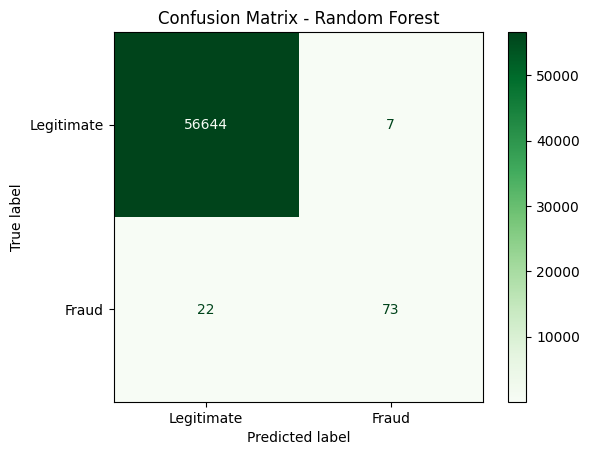

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate","Fraud"]
).plot(cmap="Greens")

plt.title("Confusion Matrix - Random Forest")

plt.show()

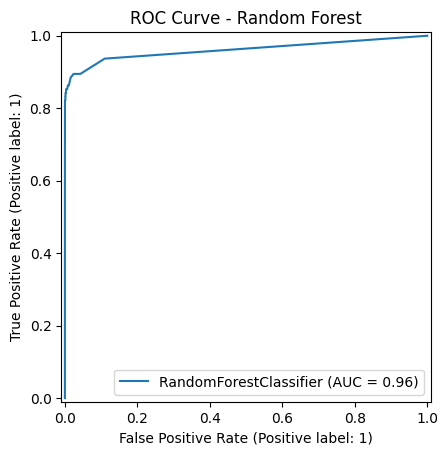

In [67]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.222660
10,V10,0.124028
12,V12,0.112320
4,V4,0.101685
17,V17,0.090413
3,V3,0.079999
11,V11,0.049800
16,V16,0.039923
2,V2,0.037733
9,V9,0.026858


/tmp/ipykernel_373/3793367439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


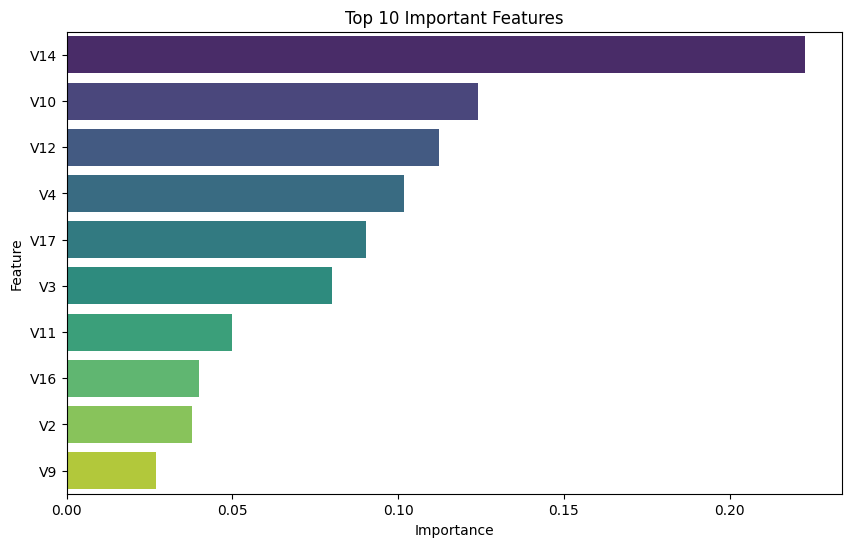

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")

plt.show()

In [70]:
print("="*40)
print("Random Forest Results")
print("="*40)

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

Random Forest Results
Precision : 0.9125
Recall    : 0.7684
ROC-AUC   : 0.9611


In [71]:
# Random Forest Summary

# A Random Forest classifier consisting of 100 decision trees was trained using the SMOTE-balanced training dataset.

# The model was evaluated using:

# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# The confusion matrix and ROC curve demonstrated the model's effectiveness in identifying fraudulent transactions while minimizing incorrect classifications.

# Feature importance analysis highlighted the variables that contributed most to the model's predictions.

In [72]:
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "ROC-AUC"],
    "Logistic Regression": [
        precision,
        recall,
        roc_auc
    ],
    "Random Forest": [
        precision_rf,
        recall_rf,
        roc_auc_rf
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Precision,0.117391,0.912500
1,Recall,0.852632,0.768421
2,ROC-AUC,0.958711,0.961093


In [73]:
# Parameter Grid

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [74]:
# Grid Search

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [76]:
from sklearn.model_selection import train_test_split

# Create a subset for hyperparameter tuning
X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=20000,      # Only 20,000 samples
    stratify=y_train_smote,
    random_state=42
)

print(X_tune.shape)
print(y_tune.shape)

(20000, 30)
(20000,)


In [77]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 150],
    "max_depth": [20, None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'max_depth': [20, None],
                                        'n_estimators': [100, 150]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [78]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 150, 'max_depth': None}

Best ROC-AUC:
0.9998603280328102


In [79]:
best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

In [80]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
roc_best = roc_auc_score(y_test, y_prob_best)

print(classification_report(y_test, y_pred_best))

print(f"Precision : {precision_best:.4f}")
print(f"Recall    : {recall_best:.4f}")
print(f"ROC-AUC   : {roc_best:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Precision : 0.9012
Recall    : 0.7684
ROC-AUC   : 0.9645


In [ ]:
# Conclusion

# In this project, a fraud detection pipeline was developed using the Credit Card Fraud Detection dataset.

# The dataset was highly imbalanced, so SMOTE was applied to balance the training data before model training.

# Two classification models, Logistic Regression and Random Forest, were trained and evaluated using Precision, Recall, and ROC-AUC instead of Accuracy, as these metrics are more appropriate for imbalanced datasets.

# Hyperparameter tuning was performed to optimize the Random Forest model, and the tuned model was selected as the final model based on its performance.

# This project demonstrates a complete supervised learning workflow, from data preprocessing and imbalance handling to model evaluation and optimization.

In [81]:
import joblib

joblib.dump(best_rf, "best_fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [82]:
from google.colab import files

files.download("best_fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>